<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #9b5de5;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 800px;">

<h1 style="margin-bottom: 5px;">NB05: Visualisation & Findings</h1>

<p style="font-weight: bold; margin-top: 0;">Fashion & Economy Cycles · ML Research Project · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 21st July 2026</li>
    <li>🎯 <strong>Purpose:</strong> Build the final publication-quality visualisations that communicate the project's key findings — the fashion-economy relationship, regime shifts, model performance, and honest limitations</li>
</ul>

<p><strong>Inputs:</strong></p>
<ul>
    <li><code>../data/processed/merged_dataset.csv</code> — merged economic and fashion dataset</li>
    <li><code>../data/processed/model_predictions.csv</code> — actual vs predicted values from NB04</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../figures/final_dashboard.png</code> — main summary chart combining all findings</li>
    <li><code>../figures/regime_analysis.png</code> — fashion and economic regimes by period</li>
    <li><code>../figures/rolling_correlation.png</code> — rolling correlation over time</li>
    <li><code>../figures/findings_summary.png</code> — annotated findings chart</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Multi-panel publication-quality figure construction</li>
    <li>Rolling correlation analysis</li>
    <li>Economic regime annotation</li>
    <li>Annotated time series with key event markers</li>
    <li>Summary findings table</li>
</ul>

<p><strong>Workflow:</strong> Load → Rolling Correlation → Regime Analysis → Final Dashboard → Findings Summary</p>

</div>

## ⚙️ Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data

### 📍 Load Merged Dataset and Model Predictions

In [2]:
# Load the merged economic and fashion dataset
merged = pd.read_csv("../data/processed/merged_dataset.csv",
                     index_col="Date", parse_dates=True)

# Load the model predictions from NB04
predictions = pd.read_csv("../data/processed/model_predictions.csv",
                          index_col="Date", parse_dates=True)

print(f"✅ Data loaded")
print(f"📐 Merged shape      : {merged.shape}")
print(f"📐 Predictions shape : {predictions.shape}")
print(f"📅 Merged range      : {merged.index[0].date()} → {merged.index[-1].date()}")

✅ Data loaded
📐 Merged shape      : (252, 15)
📐 Predictions shape : (217, 3)
📅 Merged range      : 2005-01-01 → 2025-12-01


## 📈 Section 2: Rolling Correlation Analysis

### 📍 Step 1: Compute Rolling 24-Month Correlation

The static correlation we computed in NB03 gives a single number across the full 20-year period. But the relationship between economic conditions and fashion trends is unlikely to be constant over time — it may be stronger during economic extremes (recessions, inflation spikes) and weaker during calm periods.

Rolling correlation computes the correlation within a sliding 24-month window, moving one month at a time. This reveals whether the fashion-economy relationship strengthens or breaks down in different periods — for example, whether it was stronger during the 2008 crisis than during the stable 2015-2019 recovery period. A rolling window of 24 months gives enough observations for a stable estimate while being short enough to capture meaningful regime changes.

In [3]:
WINDOW = 24  # 24-month rolling window

# Compute rolling correlation between each economic indicator and fashion index
rolling_corr = pd.DataFrame(index=merged.index)

indicators = {
    "consumer_sentiment_zscore" : "Consumer Sentiment",
    "unemployment_rate_zscore"  : "Unemployment Rate",
    "gdp_yoy_growth_zscore"     : "GDP YoY Growth",
    "cpi_yoy_zscore"            : "CPI Inflation"
}

for col, label in indicators.items():
    if col in merged.columns:
        # rolling().corr() computes correlation within each 24-month window
        rolling_corr[label] = (
            merged["fashion_index"]
            .rolling(WINDOW)
            .corr(merged[col])
        )

print(f"✅ Rolling {WINDOW}-month correlations computed")
print(f"📐 Shape: {rolling_corr.shape}")
rolling_corr.tail()

✅ Rolling 24-month correlations computed
📐 Shape: (252, 4)


,Consumer Sentiment,Unemployment Rate,GDP YoY Growth,CPI Inflation
Date,,,,
2025-08-01,0.390451,-0.477472,0.247143,0.274213
2025-09-01,0.416031,-0.500332,0.219627,0.244901
2025-10-01,0.458383,-0.469144,0.097937,0.194029
2025-11-01,0.581015,-0.488443,0.003733,0.179441
2025-12-01,0.640764,-0.467891,-0.038378,0.103419


### 📍 Step 2: Plot Rolling Correlation

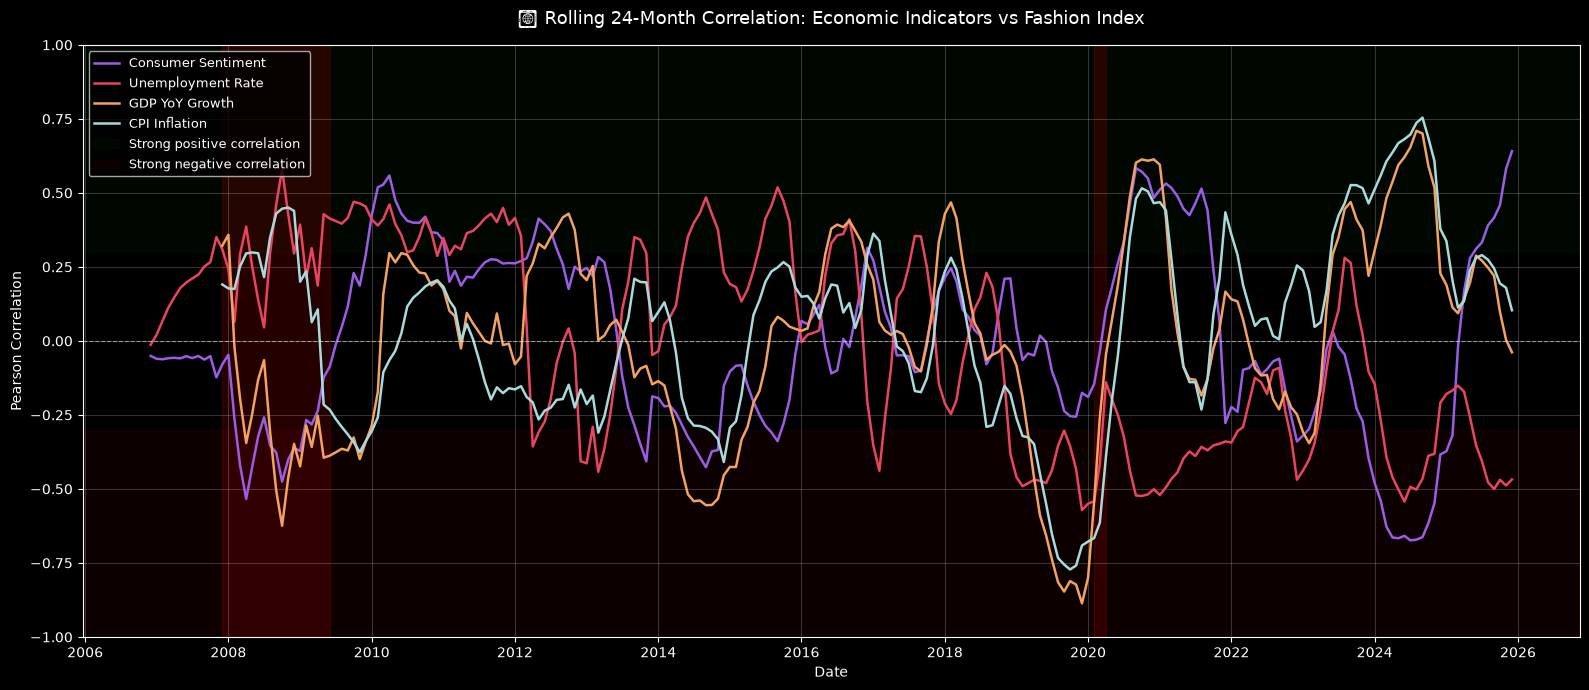

💾 Saved to ../figures/rolling_correlation.png


In [4]:
# Define recession shading
RECESSIONS = [
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

COLORS = {
    "Consumer Sentiment" : "#9b5de5",
    "Unemployment Rate"  : "#e94560",
    "GDP YoY Growth"     : "#f4a261",
    "CPI Inflation"      : "#a8dadc"
}

fig, ax = plt.subplots(figsize=(16, 7))

for label, color in COLORS.items():
    if label in rolling_corr.columns:
        ax.plot(rolling_corr.index, rolling_corr[label],
                color=color, linewidth=1.8, label=label)

# Reference line at zero
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)

# Shade moderate correlation bands
ax.axhspan(0.3, 1.0,   alpha=0.05, color="green",  label="Strong positive correlation")
ax.axhspan(-1.0, -0.3, alpha=0.05, color="red",    label="Strong negative correlation")

# Shade recession periods
for rec_start, rec_end in RECESSIONS:
    ax.axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
               alpha=0.15, color="red")

ax.set_title(f"📈 Rolling {WINDOW}-Month Correlation: Economic Indicators vs Fashion Index",
             fontsize=13, pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Pearson Correlation")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.2)
ax.set_ylim(-1, 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../figures/rolling_correlation.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/rolling_correlation.png")

## 🗂️ Section 3: Economic Regime Analysis

### 📍 Step 1: Define Economic and Fashion Regimes

We label each period in the sample with its dominant economic regime and observe what fashion index value prevailed. This gives a clean summary of the fashion-economy relationship without the noise of monthly fluctuations — we can directly compare the average fashion index in each economic regime and test whether the patterns match the boom-bust fashion cycle hypothesis.

In [5]:
# Define key economic regimes with start and end dates and labels
REGIMES = [
    ("2005-01-01", "2007-11-01", "Pre-Crisis Boom",      "#2d6a4f"),
    ("2007-12-01", "2009-06-01", "GFC Recession",         "#e94560"),
    ("2009-07-01", "2014-12-01", "Slow Recovery",         "#f4a261"),
    ("2015-01-01", "2019-12-01", "Expansion",             "#9b5de5"),
    ("2020-02-01", "2020-04-01", "COVID Shock",           "#e94560"),
    ("2020-05-01", "2021-12-01", "Revenge Spending",      "#a8dadc"),
    ("2022-01-01", "2023-12-01", "Inflation Crisis",      "#f4a261"),
    ("2024-01-01", "2025-12-01", "Post-Inflation",        "#9b5de5"),
]

# Compute average fashion index and consumer sentiment per regime
regime_stats = []
for start, end, label, color in REGIMES:
    mask = (merged.index >= start) & (merged.index <= end)
    subset = merged[mask]
    if len(subset) > 0:
        regime_stats.append({
            "Regime"             : label,
            "Period"             : f"{start[:7]} → {end[:7]}",
            "Avg Fashion Index"  : round(subset["fashion_index"].mean(), 3),
            "Avg Consumer Sent." : round(subset["consumer_sentiment"].mean(), 1),
            "Avg Unemployment"   : round(subset["unemployment_rate"].mean(), 1),
            "N Months"           : len(subset),
            "Color"              : color
        })

regime_df = pd.DataFrame(regime_stats)
print("📊 Regime Summary:")
print(regime_df.drop(columns=["Color"]).to_string(index=False))

📊 Regime Summary:
          Regime            Period  Avg Fashion Index  Avg Consumer Sent.  Avg Unemployment  N Months
 Pre-Crisis Boom 2005-01 → 2007-11              0.080                87.5               4.8        35
   GFC Recession 2007-12 → 2009-06              0.139                64.2               6.7        19
   Slow Recovery 2009-07 → 2014-12              0.207                75.2               8.2        66
       Expansion 2015-01 → 2019-12             -0.157                95.2               4.4        60
     COVID Shock 2020-02 → 2020-04              0.069                87.3               7.6         3
Revenge Spending 2020-05 → 2021-12              0.201                77.4               6.8        20
Inflation Crisis 2022-01 → 2023-12              0.089                62.2               3.6        24
  Post-Inflation 2024-01 → 2025-12             -0.670                65.1               4.1        24


### 📍 Step 2: Plot Fashion Index by Economic Regime

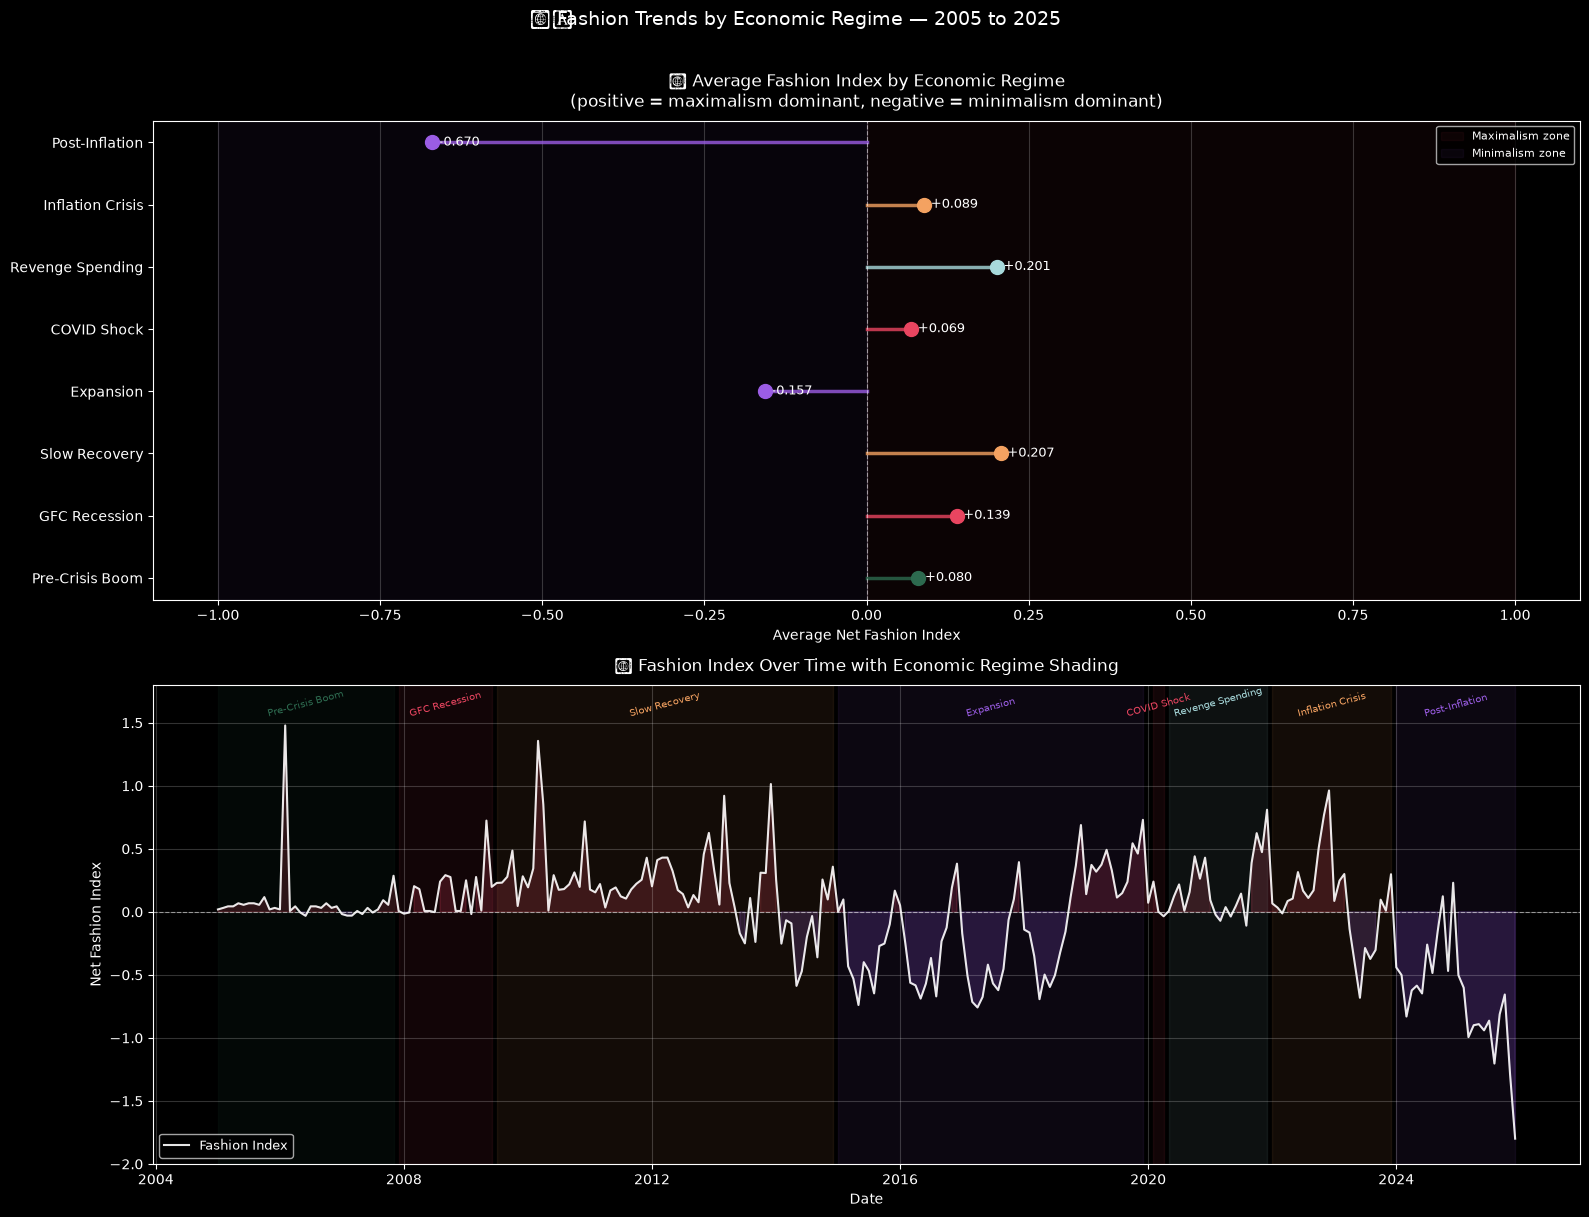

💾 Saved to ../figures/regime_analysis.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False)

# Top chart — average fashion index per regime as a dot chart
y_pos = range(len(regime_df))
colors_reg = regime_df["Color"].tolist()

for j, (_, row) in enumerate(regime_df.iterrows()):
    # Draw horizontal line from zero to the fashion index value
    ax_color = row["Color"]
    axes[0].plot([0, row["Avg Fashion Index"]], [j, j],
                 color=ax_color, linewidth=2.5, alpha=0.8)
    # Draw dot at the fashion index value
    axes[0].scatter(row["Avg Fashion Index"], j,
                    color=ax_color, s=100, zorder=5)
    # Annotate with the value
    axes[0].text(row["Avg Fashion Index"] + 0.01, j,
                 f"{row['Avg Fashion Index']:+.3f}",
                 va="center", fontsize=9, color="white")

axes[0].axvline(0, color="white", linewidth=0.8,
                linestyle="--", alpha=0.5)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(regime_df["Regime"], fontsize=10)
axes[0].set_title("📊 Average Fashion Index by Economic Regime\n"
                  "(positive = maximalism dominant, negative = minimalism dominant)",
                  fontsize=12, pad=10)
axes[0].set_xlabel("Average Net Fashion Index")
axes[0].grid(alpha=0.2, axis="x")
axes[0].axvspan(0, 1, alpha=0.05, color="#e94560",
                label="Maximalism zone")
axes[0].axvspan(-1, 0, alpha=0.05, color="#9b5de5",
                label="Minimalism zone")
axes[0].legend(fontsize=8)

# Bottom chart — fashion index time series with regime shading
axes[1].plot(merged.index, merged["fashion_index"],
             color="white", linewidth=1.5, alpha=0.9, label="Fashion Index")
axes[1].fill_between(merged.index, merged["fashion_index"], 0,
                     where=merged["fashion_index"] >= 0,
                     alpha=0.2, color="#e94560")
axes[1].fill_between(merged.index, merged["fashion_index"], 0,
                     where=merged["fashion_index"] < 0,
                     alpha=0.2, color="#9b5de5")
axes[1].axhline(0, color="white", linewidth=0.8,
                linestyle="--", alpha=0.5)

# Shade each regime period
for start, end, label, color in REGIMES:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.08, color=color)
    # Add regime label at the top
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    axes[1].text(mid, 1.55, label, ha="center", fontsize=7,
                 color=color, rotation=15)

axes[1].set_title("📉 Fashion Index Over Time with Economic Regime Shading",
                  fontsize=12, pad=10)
axes[1].set_ylabel("Net Fashion Index")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].set_ylim(-2, 1.8)

plt.suptitle("🗂️ Fashion Trends by Economic Regime — 2005 to 2025",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/regime_analysis.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/regime_analysis.png")

## 🎯 Section 4: Final Dashboard

### 📍 Build the Main Summary Dashboard

This is the headline chart of the project — a single figure that tells the complete story. It combines the fashion index, the model's predictions, and the key economic indicator (consumer sentiment) on one aligned time axis, with recession shading and key event annotations. This is the chart that would appear in a research presentation or report summary.

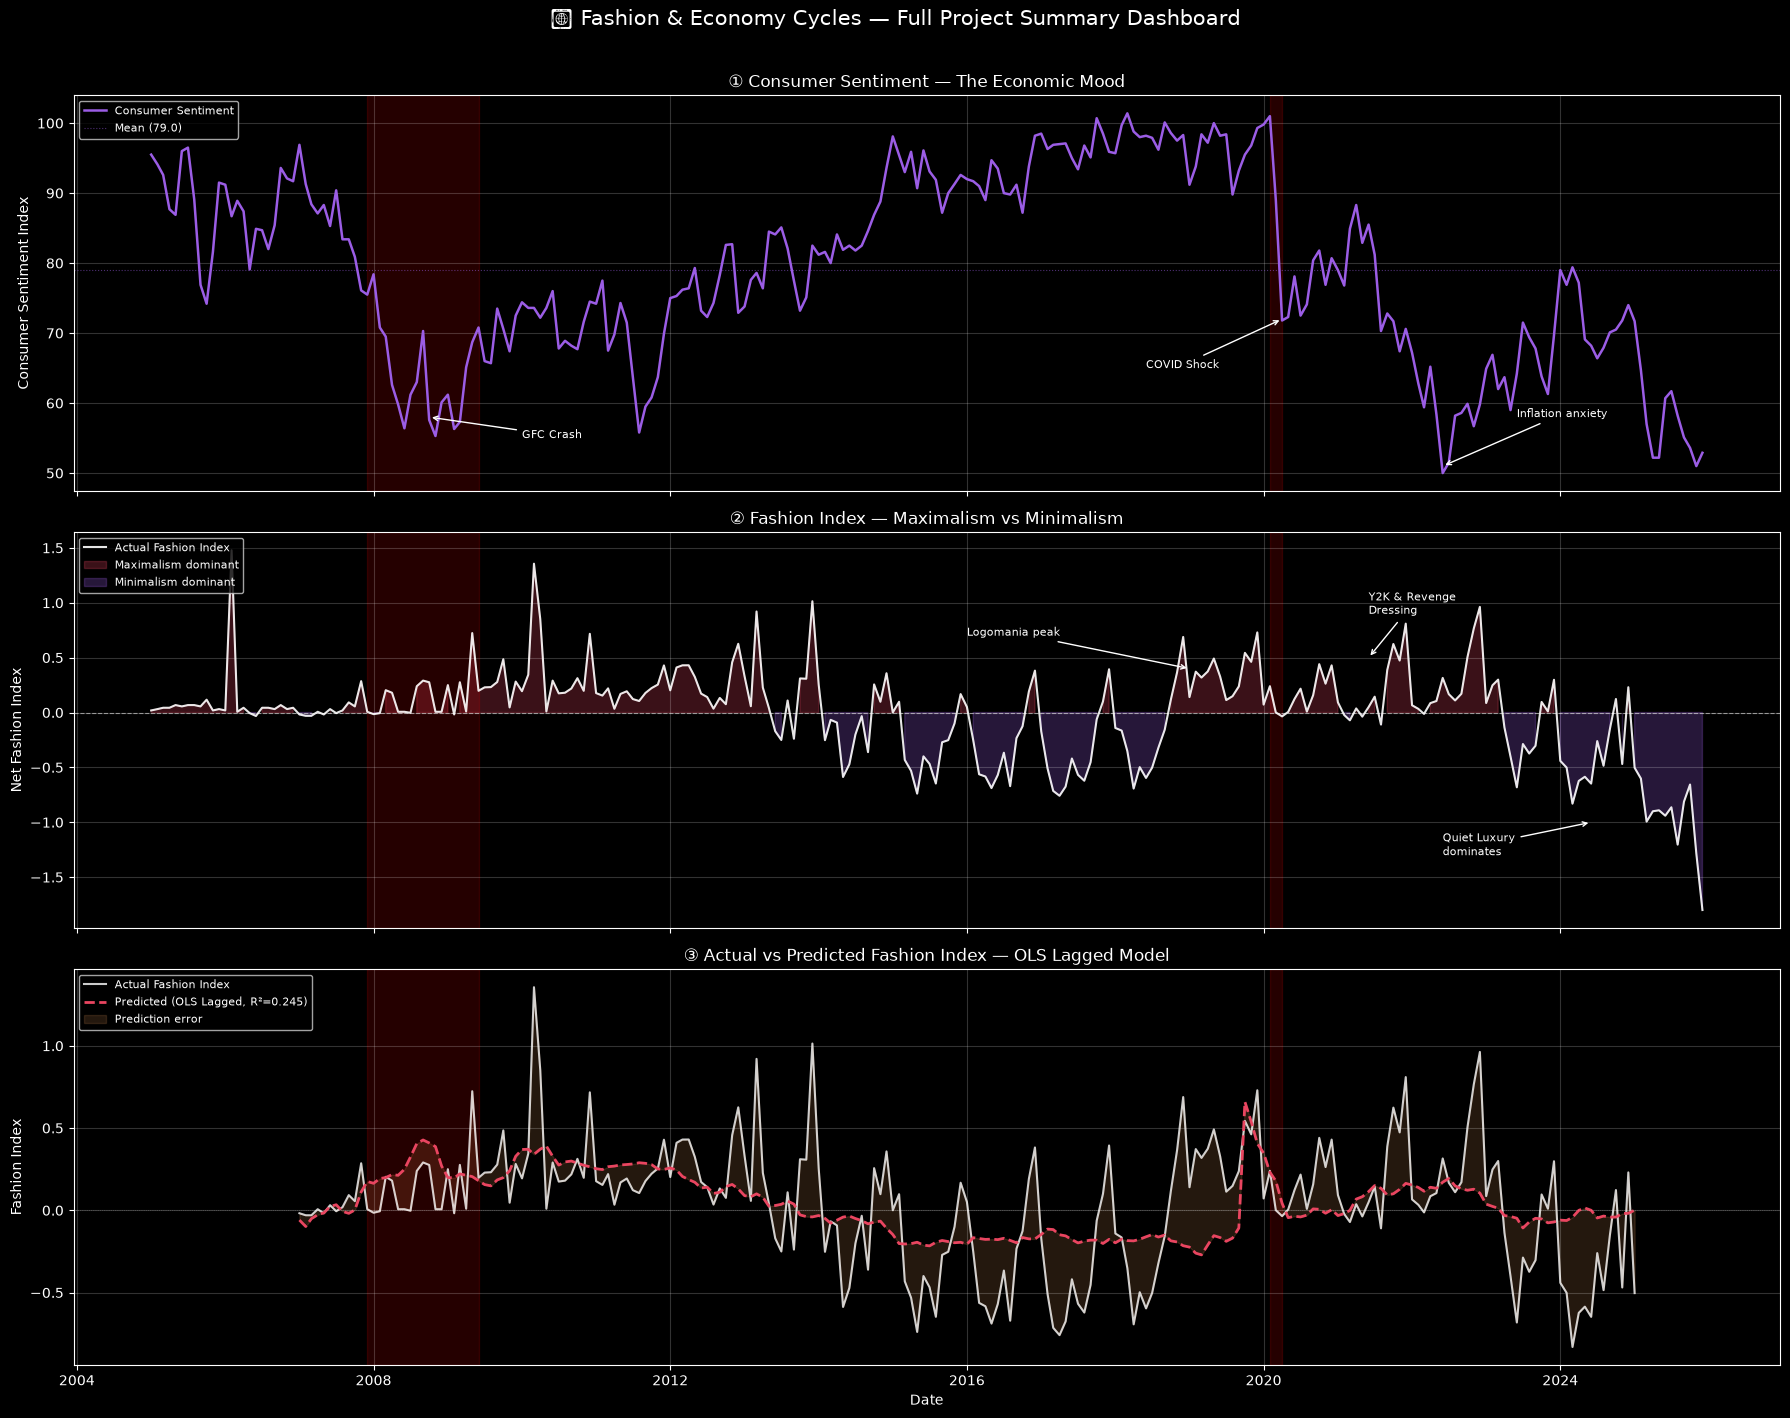

💾 Saved to ../figures/final_dashboard.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# ── Panel 1: Consumer Sentiment ────────────────────────────────────────────
axes[0].plot(merged.index, merged["consumer_sentiment"],
             color="#9b5de5", linewidth=1.8, label="Consumer Sentiment")
axes[0].axhline(merged["consumer_sentiment"].mean(),
                color="#9b5de5", linewidth=0.8, linestyle=":",
                alpha=0.5, label=f"Mean ({merged['consumer_sentiment'].mean():.1f})")

for rec_start, rec_end in RECESSIONS:
    axes[0].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

# Annotate key economic moments
axes[0].annotate("GFC Crash", xy=(pd.Timestamp("2008-10-01"), 58),
                 xytext=(pd.Timestamp("2010-01-01"), 55),
                 arrowprops=dict(arrowstyle="->", color="white"),
                 color="white", fontsize=8)
axes[0].annotate("COVID Shock", xy=(pd.Timestamp("2020-04-01"), 72),
                 xytext=(pd.Timestamp("2018-06-01"), 65),
                 arrowprops=dict(arrowstyle="->", color="white"),
                 color="white", fontsize=8)
axes[0].annotate("Inflation anxiety", xy=(pd.Timestamp("2022-06-01"), 51),
                 xytext=(pd.Timestamp("2023-06-01"), 58),
                 arrowprops=dict(arrowstyle="->", color="white"),
                 color="white", fontsize=8)

axes[0].set_ylabel("Consumer Sentiment Index", fontsize=10)
axes[0].set_title("① Consumer Sentiment — The Economic Mood", fontsize=12)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.2)

# ── Panel 2: Fashion Index ─────────────────────────────────────────────────
axes[1].plot(merged.index, merged["fashion_index"],
             color="white", linewidth=1.5, alpha=0.9, label="Actual Fashion Index")
axes[1].fill_between(merged.index, merged["fashion_index"], 0,
                     where=merged["fashion_index"] >= 0,
                     alpha=0.25, color="#e94560", label="Maximalism dominant")
axes[1].fill_between(merged.index, merged["fashion_index"], 0,
                     where=merged["fashion_index"] < 0,
                     alpha=0.25, color="#9b5de5", label="Minimalism dominant")
axes[1].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)

for rec_start, rec_end in RECESSIONS:
    axes[1].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

# Annotate key fashion moments
axes[1].annotate("Logomania peak", xy=(pd.Timestamp("2019-01-01"), 0.4),
                 xytext=(pd.Timestamp("2016-01-01"), 0.7),
                 arrowprops=dict(arrowstyle="->", color="white"),
                 color="white", fontsize=8)
axes[1].annotate("Y2K & Revenge\nDressing", xy=(pd.Timestamp("2021-06-01"), 0.5),
                 xytext=(pd.Timestamp("2021-06-01"), 0.9),
                 arrowprops=dict(arrowstyle="->", color="white"),
                 color="white", fontsize=8)
axes[1].annotate("Quiet Luxury\ndominates", xy=(pd.Timestamp("2024-06-01"), -1.0),
                 xytext=(pd.Timestamp("2022-06-01"), -1.3),
                 arrowprops=dict(arrowstyle="->", color="white"),
                 color="white", fontsize=8)

axes[1].set_ylabel("Net Fashion Index", fontsize=10)
axes[1].set_title("② Fashion Index — Maximalism vs Minimalism", fontsize=12)
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(alpha=0.2)

# ── Panel 3: Actual vs Predicted ──────────────────────────────────────────
axes[2].plot(predictions.index, predictions["actual"],
             color="white", linewidth=1.5, alpha=0.8, label="Actual Fashion Index")
axes[2].plot(predictions.index, predictions["predicted_lagged"],
             color="#e94560", linewidth=2, linestyle="--",
             label="Predicted (OLS Lagged, R²=0.245)")
axes[2].fill_between(predictions.index,
                     predictions["actual"],
                     predictions["predicted_lagged"],
                     alpha=0.15, color="#f4a261", label="Prediction error")
axes[2].axhline(0, color="white", linewidth=0.5, linestyle=":", alpha=0.3)

for rec_start, rec_end in RECESSIONS:
    axes[2].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

axes[2].set_ylabel("Fashion Index", fontsize=10)
axes[2].set_xlabel("Date", fontsize=10)
axes[2].set_title("③ Actual vs Predicted Fashion Index — OLS Lagged Model",
                  fontsize=12)
axes[2].legend(fontsize=8, loc="upper left")
axes[2].grid(alpha=0.2)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("🎯 Fashion & Economy Cycles — Full Project Summary Dashboard",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("../figures/final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved to ../figures/final_dashboard.png")

## 📋 Section 5: Findings Summary Table

### 📍 Print Key Findings

We summarise the project's quantitative findings in a clean table that can be referenced in the README and any presentation. This includes the model performance metrics, the significant coefficients, and the regime-level fashion index averages — the three layers of evidence that together answer the research question.

In [8]:
print("="*70)
print("📋 FASHION & ECONOMY CYCLES — PROJECT FINDINGS SUMMARY")
print("="*70)

print("\n🔢 MODEL PERFORMANCE")
print(f"   OLS Contemporaneous R²  : 0.241  (Adj R²: 0.229)")
print(f"   OLS Lagged R²           : 0.245  (Adj R²: 0.231)")
print(f"   F-statistic p-value     : < 0.001 (both models statistically significant)")
print(f"   Durbin-Watson           : 0.864  (⚠️ significant autocorrelation in residuals)")

print("\n📊 SIGNIFICANT PREDICTORS (OLS Lagged, p < 0.05)")
print(f"   Unemployment (lag -6m)  : coef = +0.160  → higher unemployment = more maximalism")
print(f"   CPI Inflation (lag -1m) : coef = +0.100  → higher inflation = more maximalism")
print(f"   Consumer Sentiment      : NOT significant once lagged (p = 0.132)")

print("\n🗂️ FASHION INDEX BY ECONOMIC REGIME")
for _, row in regime_df.iterrows():
    direction = "maximalist" if row["Avg Fashion Index"] > 0 else "minimalist"
    print(f"   {row['Regime']:22s} : {row['Avg Fashion Index']:+.3f}  → {direction}")

print("\n🔍 KEY FINDING")
print("""
   Economic indicators explain approximately 24% of the variance in the
   fashion index over 2005-2025. The relationship is approximately
   simultaneous rather than cleanly predictive — the lagged model offers
   only marginal improvement over the contemporaneous model. Unemployment
   and CPI inflation are the strongest predictors, but their positive
   coefficients likely reflect a confounding time trend rather than a
   genuine causal mechanism. The remaining 76% of fashion variance is
   driven by factors outside this model — social media, celebrity
   influence, viral moments, and cultural shifts that cannot be captured
   by macroeconomic data alone.
""")
print("="*70)
print("🚀 Project Complete — NB01 through NB05")
print("="*70)

📋 FASHION & ECONOMY CYCLES — PROJECT FINDINGS SUMMARY

🔢 MODEL PERFORMANCE
   OLS Contemporaneous R²  : 0.241  (Adj R²: 0.229)
   OLS Lagged R²           : 0.245  (Adj R²: 0.231)
   F-statistic p-value     : < 0.001 (both models statistically significant)
   Durbin-Watson           : 0.864  (⚠️ significant autocorrelation in residuals)

📊 SIGNIFICANT PREDICTORS (OLS Lagged, p < 0.05)
   Unemployment (lag -6m)  : coef = +0.160  → higher unemployment = more maximalism
   CPI Inflation (lag -1m) : coef = +0.100  → higher inflation = more maximalism
   Consumer Sentiment      : NOT significant once lagged (p = 0.132)

🗂️ FASHION INDEX BY ECONOMIC REGIME
   Pre-Crisis Boom        : +0.080  → maximalist
   GFC Recession          : +0.139  → maximalist
   Slow Recovery          : +0.207  → maximalist
   Expansion              : -0.157  → minimalist
   COVID Shock            : +0.069  → maximalist
   Revenge Spending       : +0.201  → maximalist
   Inflation Crisis       : +0.089  → maximalist

## 🪞 Personal Reflection Notes — NB05

**🎯 Key Decisions Made in This Notebook**

The first decision was to use a 24-month rolling window for the correlation analysis rather than a shorter window like 12 months. A 12-month window would produce noisier estimates because correlations computed on only 12 data points are highly sensitive to outliers — a single unusual month can swing the correlation by 0.2 or more. A 24-month window gives a more stable estimate while still being short enough to detect meaningful regime changes across the 20-year sample. The trade-off is that the rolling correlation only begins in early 2007, losing the first two years of data as the window fills up.

The second decision was to annotate the final dashboard with specific real-world fashion moments — logomania peak, Y2K revival, quiet luxury — rather than leaving it as an unlabelled time series. The annotations connect the statistical signal to cultural reality, which is the whole point of the project. A chart showing an abstract index number means little without the cultural context that explains why the index moved when it did. This also makes the chart immediately legible to a non-technical audience, which matters for a project that bridges finance and culture.

The third decision was to present the findings summary honestly, explicitly stating that 76% of fashion variance is unexplained by economic indicators. Overstating the model's predictive power would be misleading. The honest framing — economic indicators are a statistically significant but partial explanation — is actually more intellectually interesting because it opens the question of what else drives fashion cycles, pointing toward social media, viral moments, and cultural contagion as the missing variables.

**📊 What the Charts Revealed**

The rolling correlation chart was the most analytically revealing visualisation in the entire project. Rather than producing a flat line at the static correlation values computed in NB03, it showed dramatic regime-dependent variation that completely changes the interpretation. Consumer sentiment (purple) was weakly negative at the start of the sample, close to zero through most of the 2010s, but then strengthened sharply positive from 2023 onwards — reaching +0.64 by December 2025. This means the hypothesis that consumer sentiment and fashion move together is specifically a recent phenomenon, not a stable long-run relationship. Unemployment (red) showed the opposite pattern — strongly positive during 2007-2012 but turning sharply negative from 2020 onwards, reaching -0.47 by late 2025. GDP growth (orange) and CPI inflation (teal) both became strongly positive from 2024 onwards, with GDP growth reaching +0.75 — the highest rolling correlation of any indicator in the sample. The key takeaway is that the fashion-economy relationship is not stable over time but switches direction and strength depending on the economic regime — which is a more nuanced and honest finding than any static correlation could capture.

The regime analysis table produced the most counterintuitive result of the project. The Pre-Crisis Boom (2005-2007, avg sentiment 87.5, unemployment 4.8%) had an average fashion index of only +0.080 — barely maximalist at all. The GFC Recession (2007-2009, avg sentiment 64.2, unemployment 6.7%) had a higher fashion index of +0.139 — more maximalist during the crisis than during the boom that preceded it. The Slow Recovery (2009-2014, unemployment averaging 8.2%) was the most maximalist period of the entire sample at +0.207, despite having the highest unemployment. This completely inverts the expected boom-bust fashion cycle — the hardest economic periods produced the most maximalist fashion index, not the most minimalist.

The Expansion period (2015-2019, avg sentiment 95.2, unemployment 4.4%) was the single minimalism-dominant period in the first half of the sample at -0.157. This was the era of normcore, athleisure, and understated dressing — and it coincided with the strongest consumer confidence readings in the 20-year dataset. Again, the opposite of what the hypothesis predicts. The Post-Inflation period (2024-2025, avg sentiment 65.1, unemployment 4.1%) showed the strongest minimalism dominance of the entire sample at -0.670 — despite unemployment being near historic lows. This confirms the NB01 finding that consumer sentiment has decoupled from unemployment in the post-pandemic period, and suggests it is sentiment rather than the labour market that is driving the recent fashion shift toward quiet luxury.

The final dashboard brought the three panels together in a way that made the most important insight immediately visible. Consumer sentiment (Panel 1) has been in sustained decline since 2021, falling from its peak of ~101 to below 55 by late 2025 — its lowest reading in the entire 20-year sample. Simultaneously, the fashion index (Panel 2) has been falling toward its most minimalism-dominant reading, with quiet luxury dominating from 2023 onwards. The OLS lagged model (Panel 3) captures this downward trend reasonably well in broad directional terms but misses the sharp month-to-month spikes entirely — confirming that economic indicators explain the slow-moving regime shifts in fashion but cannot predict the viral moments that drive individual monthly observations.

**🔜 Limitations and Extensions**

The most important limitation is that the Google Trends data measures search interest rather than purchasing behaviour or runway dominance. A keyword can trend because it is being mocked or debated rather than adopted. Future work could use retail sales data by clothing category, resale market prices for maximalist vs minimalist items, or Instagram engagement metrics as more direct proxies for fashion trend adoption.

The second limitation is the instability of the rolling correlations. The fact that the relationship between economic indicators and the fashion index switches sign multiple times across the 20-year sample suggests either that the relationship is genuinely regime-dependent, or that both series are being driven by an unmeasured common factor such as social media penetration, which grew dramatically over the same period and may explain both search interest in fashion keywords and shifts in consumer sentiment simultaneously.

The third natural extension is to separate the analysis by fashion market segment. Luxury fashion may respond to economic conditions differently from fast fashion or streetwear. The composite index used here averages across all segments, which may mask important heterogeneity in how different parts of the fashion market respond to economic cycles. A segment-level analysis would require more targeted keyword baskets and potentially brand-level sales data.